# Závislost mezi Metascore a hodnocení hráčů

### 1. Úvodní otázka
Existuje statisticky významná závislost mezi Metascore a hodnocení hráčů na Metacritic?

### 2. Sběr dat
Data jsem získal z: https://www.kaggle.com/datasets/patkle/metacritic-scores-for-games-movies-tv-and-music

### 3. Struktura dat

Dataset obsahuje informace o videohrách získané z Metacriticu a souvisejících zdrojů. Každý řádek představuje jednu hru.

### Sloupce:

- **id** – unikátní identifikátor hry
- **metascore** – průměrné hodnocení od kritiků (0–100)
- **platform** – platforma (např. PC, PlayStation, Xbox)
- **release_date** – datum vydání hry
- **sort_no** – interní pořadí
- **summary** – krátký popis hry
- **title** – název hry
- **user_score** – průměrné hodnocení hráčů (obvykle 0–10, po úpravě sjednoceno)

### 4. Načtení dat

In [103]:
import pandas as pd
df = pd.read_csv("games.csv")
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20022 entries, 0 to 20021
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            20022 non-null  int64 
 1   metascore     20022 non-null  int64 
 2   platform      20022 non-null  object
 3   release_date  20022 non-null  object
 4   sort_no       20022 non-null  int64 
 5   summary       19930 non-null  object
 6   title         20022 non-null  object
 7   user_score    20022 non-null  object
dtypes: int64(3), object(5)
memory usage: 1.2+ MB


,id,metascore,platform,release_date,sort_no,summary,title,user_score
0,543718,91,PC,"August 18, 2020",301,"From light planes to wide-body jets, fly highl...",Microsoft Flight Simulator,7.1
1,555108,91,PC,"December 8, 2022",302,"Take up your sword, channel your magic or boar...",Chained Echoes,8.7
2,106820,91,PlayStation 2,"November 7, 2005",303,"Strap on your Guitar Hero SG controller, plug-...",Guitar Hero,8.5
3,110775,91,PC,"November 13, 2008",304,"Players last visited Northrend in ""Warcraft II...",World of Warcraft: Wrath of the Lich King,7.7
4,142864,91,Wii,"October 26, 2010",305,Rock Band returns with the third iteration of ...,Rock Band 3,6.8


### 5. Formulace hypotéz
H₀: Mezi hodnocením kritiků a hráčů neexistuje lineární vztah.

H₁: Mezi hodnocením kritiků a hráčů existuje lineární vztah.

### 6. Testování hypotéz

Nejprve data očistíme a sjednotíme škály hodnocení, poté ověříme jejich vzájemnou závislost pomocí Pearsonova korelačního testu. Na základě p-hodnoty rozhodneme, zda lze zamítnout nulovou hypotézu o neexistenci vztahu, a sílu vazby posoudíme pomocí korelačního koeficientu. Následně doplníme analýzu lineární regresí, která ukáže, jak dobře lze uživatelské hodnocení vysvětlit pomocí Metascore.

In [104]:
import pandas as pd
from scipy.stats import pearsonr

df = pd.read_csv("games.csv")
df["user_score"] = pd.to_numeric(df["user_score"], errors="coerce") * 10
nan_rows = df[df["user_score"].isna()]
clean_df = df[["metascore", "user_score"]].dropna()

r, p = pearsonr(clean_df["metascore"], clean_df["user_score"])
print("\nPearson r:", r)
print("p-value:", p)


Pearson r: 0.5201247358416836
p-value: 0.0


### 7. Výsledky Pearsonova testu
---
🟦 Pearson r = 0.52

#### To znamená:

Středně silná pozitivní korelace

Když roste Metascore, obvykle roste i User Score

Ale je tam hodně rozptylu => kritici a hráči se často shodují, ale ne vždy

---
🟦 p-value ≈ 0

předpokládám že p-hodnota je > 0 je je tak malá že ji program zaokrouhlil dolů

#### To znamená:

výsledek je statisticky významný
nulovou hypotézu (že žádný vztah neexistuje) zamítáme

### 8. Vizualizace

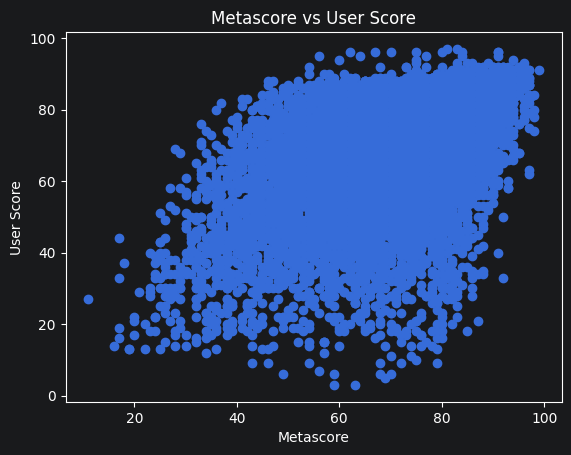

In [105]:
import matplotlib.pyplot as plt

df["user_score"] = df["user_score"]
plt.scatter(df["metascore"], df["user_score"])
plt.xlabel("Metascore")
plt.ylabel("User Score")
plt.title("Metascore vs User Score")
plt.show()

### 9. Lineární regrese

In [106]:
from sklearn.linear_model import LinearRegression

X = clean_df[["metascore"]]
y = clean_df["user_score"]

model = LinearRegression()
model.fit(X, y)

print("Koeficient (β1):", model.coef_[0])
print("Intercept (β0):", model.intercept_)
print("R²:", model.score(X, y))

Koeficient (β1): 0.5800756974074383
Intercept (β0): 28.277344802668303
R²: 0.2705297408343812


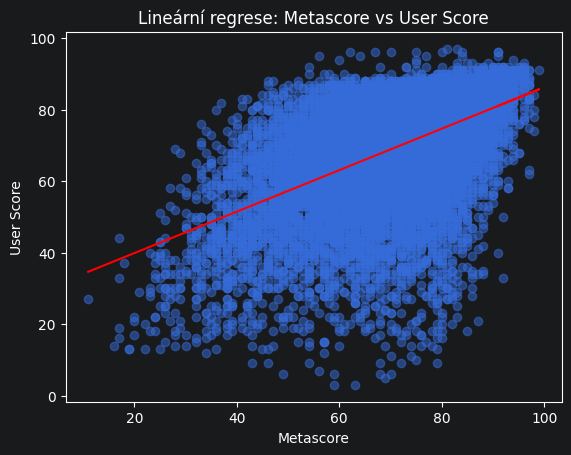

In [109]:
import matplotlib.pyplot as plt

plt.scatter(clean_df["metascore"], clean_df["user_score"], alpha=0.5)
plt.plot(
    clean_df["metascore"],
    model.predict(X),
    color="red"
)

plt.xlabel("Metascore")
plt.ylabel("User Score")
plt.title("Lineární regrese: Metascore vs User Score")
plt.show()

### 10. Výsledky lineární regrese
Výsledky lineární regrese ukazují pozitivní vztah mezi Metascore a User Score, což znamená, že vyšší hodnocení kritiků je v průměru spojeno i s vyšším hodnocením hráčů.

Zároveň však hodnota R² naznačuje, že Metascore není úplným ukazatelem oblíbenosti hry mezi hráči.
To znamená, že hráčské hodnocení je ovlivněno i dalšími faktory.

### 11. Závěr

Cílem této práce bylo analyzovat vztah mezi hodnocením kritiků (Metascore) a hodnocením hráčů (User Score) u videoher a zjistit, zda mezi těmito dvěma pohledy existuje souvislost.

Na základě provedené korelační analýzy byla zjištěna středně silná pozitivní korelace (r ≈ 0.53), která ukazuje, že hry s vyšším Metascore mají v průměru také vyšší uživatelské hodnocení. Tento vztah byl zároveň statisticky významný (p < 0.05).

Lineární regresní model dále ukázal, že Metascore vysvětluje pouze část variability v uživatelském hodnocení. To znamená, že i když existuje zřetelný trend mezi oběma proměnnými, hodnocení hráčů je ovlivněno i dalšími faktory, které model nezachycuje.

Celkově lze říci, že hodnocení kritiků a hráčů jsou ve střední míře v souladu, avšak mezi nimi existují výrazné odchylky.